<a href="https://colab.research.google.com/github/jithin8050/house-price-prediction/blob/main/Liver_Tumor_Detection_Using_Deep_Learning_(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nibabel pydicom opencv-python torch torchvision torchaudio
!pip install segmentation-models-pytorch albumentations tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.7 MB/s eta 0:00:00


In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 96.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=6e05b039b06895d24c61ec251dab9dd547e44c017d47c8ea5c722428ba9a1505
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
!pip install monai


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 50.7 MB/s eta 0:00:00


In [ ]:
from PIL import Image

from IPython.display import Image as DisplayImage, display


In [ ]:
!mkdir -p ~/.kaggle
from google.colab import files
files.upload()   # A small window will pop up → choose the kaggle.json file you downloaded


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hello9990","key":"82f10532167e39958e540652a9bf2b33"}'}

In [ ]:
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets list | head


ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
anandshaw2001/amazon-product-sales-2025                         Amazon Diwali Product Sales 2025                        397394  2025-11-02 06:45:32.877000           1088         26  1.0              
ahmeduzaki/global-earthquake-tsunami-risk-assessment-dataset    Global Earthquake-Tsunami Risk Assessment Dataset        16151  2025-10-01 16:35:53.273000          18695        632  1.0              
ahmadrazakashif/bmw-worldwide-sales-records-20102024            BMW Worldwide Sales Records (2010–2024)                 853348  2025-09-20 14:39:45.280000          21613        416  1.0              


In [ ]:
!kaggle datasets download -d andrewmvd/liver-tumor-segmentation
!unzip liver-tumor-segmentation.zip -d /content/lits_dataset


Dataset URL: https://www.kaggle.com/datasets/andrewmvd/liver-tumor-segmentation
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
 99% 4.80G/4.84G [01:25<00:02, 15.7MB/s]
100% 4.84G/4.84G [01:25<00:00, 60.6MB/s]
Archive:  liver-tumor-segmentation.zip
  inflating: /content/lits_dataset/segmentations/segmentation-0.nii  
  inflating: /content/lits_dataset/segmentations/segmentation-1.nii  
  inflating: /content/lits_dataset/segmentations/segmentation-10.nii  
  inflating: /content/lits_dataset/segmentations/segmentation-100.nii  
  inflating: /content/lits_dataset/segmentations/segmentation-101.nii  
  inflating: /content/lits_dataset/segmentations/segmentation-102.nii  
  inflating: /content/lits_dataset/segmentations/segmentation-103.nii  
  inflating: /content/lits_dataset/segmentations/segmentation-104.nii  
  inflating: /content/lits_dataset/segmentations/segmentation-105.nii  
  inflating: /content/lits_dataset/segmentations/segmentation-106.ni

In [ ]:
!ls /content/lits_dataset


segmentations  volume_pt1  volume_pt2  volume_pt3  volume_pt4  volume_pt5


In [ ]:
!mkdir /content/lits_dataset/volumes_combined
!mv /content/lits_dataset/volume_pt*/volume* /content/lits_dataset/volumes_combined/


In [ ]:
!ls /content/lits_dataset/volumes_combined | head


volume-0.nii
volume-10.nii
volume-11.nii
volume-12.nii
volume-13.nii
volume-14.nii
volume-15.nii
volume-16.nii
volume-17.nii
volume-18.nii


In [ ]:
!ls /content/lits_dataset/segmentations | head


segmentation-0.nii
segmentation-100.nii
segmentation-101.nii
segmentation-102.nii
segmentation-103.nii
segmentation-104.nii
segmentation-105.nii
segmentation-106.nii
segmentation-107.nii
segmentation-108.nii


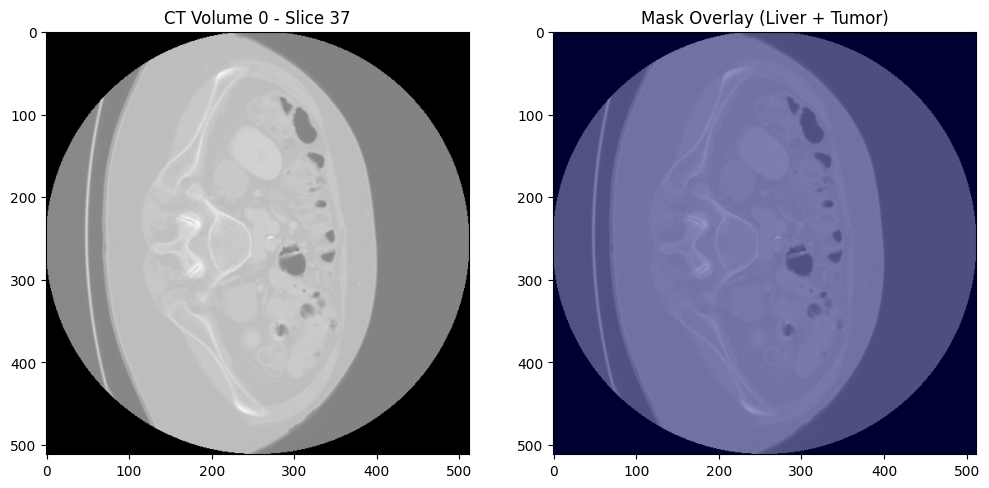

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

# Pick any sample index
idx = 0
img_path = f"/content/lits_dataset/volumes_combined/volume-{idx}.nii"
mask_path = f"/content/lits_dataset/segmentations/segmentation-{idx}.nii"

# Load NIfTI data
img = nib.load(img_path).get_fdata()
mask = nib.load(mask_path).get_fdata()

# Select a middle slice
slice_idx = img.shape[2] // 2
image_slice = img[:, :, slice_idx]
mask_slice = mask[:, :, slice_idx]

# Normalize for visualization
image_slice = (image_slice - np.min(image_slice)) / (np.max(image_slice) - np.min(image_slice))

# Plot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image_slice, cmap='gray')
plt.title(f"CT Volume {idx} - Slice {slice_idx}")

plt.subplot(1, 2, 2)
plt.imshow(image_slice, cmap='gray')
plt.imshow(mask_slice, alpha=0.4, cmap='jet')
plt.title(f"Mask Overlay (Liver + Tumor)")
plt.show()


In [ ]:
import nibabel as nib
import numpy as np
import cv2
import os
from tqdm import tqdm

# Paths
img_dir = "/content/lits_dataset/volumes_combined"
mask_dir = "/content/lits_dataset/segmentations"
output_img_dir = "/content/lits_dataset/processed/images"
output_mask_dir = "/content/lits_dataset/processed/masks"

os.makedirs(output_img_dir, exist_ok=True)
os.makedirs(output_mask_dir, exist_ok=True)

# Resize all slices to this shape (for U-Net)
IMG_SIZE = 256

# Loop over each volume and its corresponding mask
for idx in tqdm(range(len(os.listdir(img_dir)))):
    img_path = os.path.join(img_dir, f"volume-{idx}.nii")
    mask_path = os.path.join(mask_dir, f"segmentation-{idx}.nii")

    if not os.path.exists(img_path) or not os.path.exists(mask_path):
        continue

    img = nib.load(img_path).get_fdata()
    mask = nib.load(mask_path).get_fdata()

    # Normalize CT intensity to [0,1]
    img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)

    # Loop through each slice of the 3D volume
    for i in range(img.shape[2]):
        img_slice = cv2.resize(img[:, :, i], (IMG_SIZE, IMG_SIZE))
        mask_slice = cv2.resize(mask[:, :, i], (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        # Skip empty slices (no liver/tumor)
        if np.max(mask_slice) == 0:
            continue

        img_slice_uint8 = (img_slice * 255).astype(np.uint8)
        mask_slice_uint8 = (mask_slice * 255).astype(np.uint8)

        # Save as PNG
        cv2.imwrite(f"{output_img_dir}/img_{idx}_{i}.png", img_slice_uint8)
        cv2.imwrite(f"{output_mask_dir}/mask_{idx}_{i}.png", mask_slice_uint8)

print("✅ Conversion complete! 2D slices ready for training.")
print(f"Images saved in: {output_img_dir}")
print(f"Masks saved in: {output_mask_dir}")


100%|██████████| 51/51 [03:29<00:00,  4.10s/it]

✅ Conversion complete! 2D slices ready for training.
Images saved in: /content/lits_dataset/processed/images
Masks saved in: /content/lits_dataset/processed/masks


In [ ]:
!ls /content/lits_dataset/processed/images | head
!ls /content/lits_dataset/processed/masks | head


img_0_45.png
img_0_46.png
img_0_47.png
img_0_48.png
img_0_49.png
img_0_50.png
img_0_51.png
img_0_52.png
img_0_53.png
img_0_54.png
mask_0_45.png
mask_0_46.png
mask_0_47.png
mask_0_48.png
mask_0_49.png
mask_0_50.png
mask_0_51.png
mask_0_52.png
mask_0_53.png
mask_0_54.png


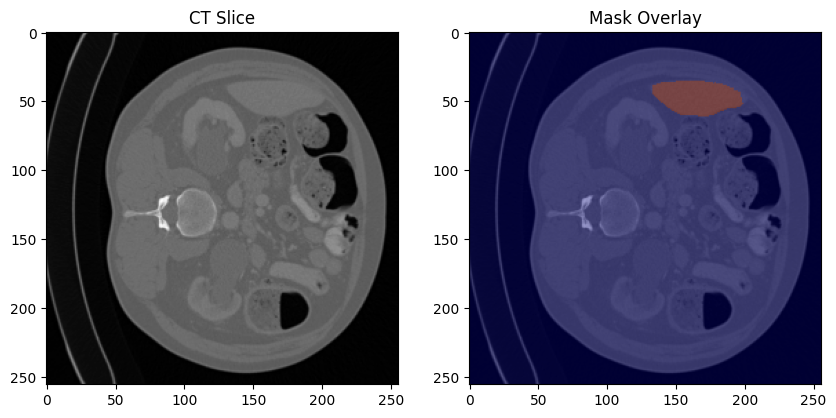

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random

img_folder = "/content/lits_dataset/processed/images"
mask_folder = "/content/lits_dataset/processed/masks"

files = os.listdir(img_folder)
sample = random.choice(files)

img = cv2.imread(os.path.join(img_folder, sample), cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(os.path.join(mask_folder, sample.replace("img_", "mask_")), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("CT Slice")

plt.subplot(1,2,2)
plt.imshow(img, cmap='gray')
plt.imshow(mask, alpha=0.4, cmap='jet')
plt.title("Mask Overlay")
plt.show()


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import cv2
import numpy as np
import os
from sklearn.model_selection import train_test_split
from albumentations import (
    Compose, HorizontalFlip, VerticalFlip, RandomRotate90,
    ShiftScaleRotate, RandomBrightnessContrast
)
from albumentations.pytorch import ToTensorV2
from PIL import Image

# Paths
image_dir = "/content/lits_dataset/processed/images"
mask_dir = "/content/lits_dataset/processed/masks"

# List of image files
image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))

# Train/validation split
train_imgs, val_imgs = train_test_split(image_files, test_size=0.2, random_state=42)

# --- Augmentation & preprocessing transforms ---

train_transform = Compose([
    HorizontalFlip(p=0.5),
    VerticalFlip(p=0.5),
    RandomRotate90(p=0.5),
    ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=20, p=0.5),
    RandomBrightnessContrast(p=0.3),
    ToTensorV2()
])

val_transform = Compose([
    ToTensorV2()
])

# --- Custom Dataset Class ---
class LiverDataset(Dataset):
    def __init__(self, image_list, image_dir, mask_dir, transform=None):
        self.image_list = image_list
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        img_name = self.image_list[idx]
        mask_name = img_name.replace("img_", "mask_")

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        # Load grayscale image and mask
        image = np.array(Image.open(img_path).convert("L"))
        mask = np.array(Image.open(mask_path).convert("L"))

        # Normalize [0,1]
        image = image / 255.0
        mask = mask / 255.0
        mask = (mask > 0.5).astype(np.float32)  # ensure binary mask

        # Albumentations needs dict format
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask.unsqueeze(0)  # Add channel dim for mask

# --- Create dataset objects ---
train_dataset = LiverDataset(train_imgs, image_dir, mask_dir, transform=train_transform)
val_dataset = LiverDataset(val_imgs, image_dir, mask_dir, transform=val_transform)

# --- Create dataloaders ---
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)

print(f"✅ Data ready: {len(train_dataset)} train samples, {len(val_dataset)} validation samples")


✅ Data ready: 5439 train samples, 1360 validation samples


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


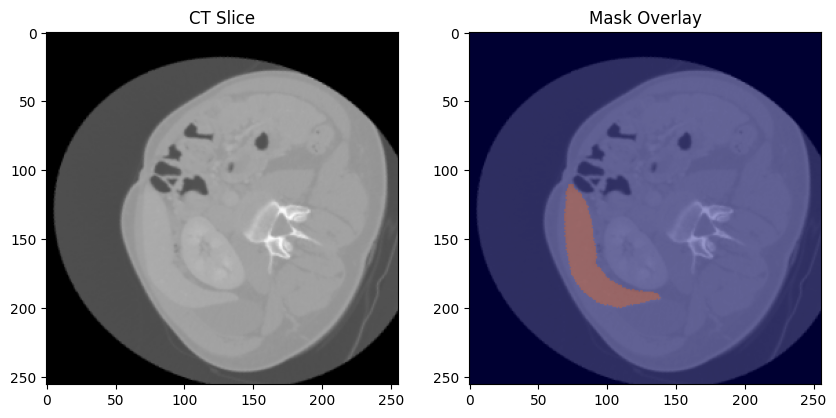

In [ ]:
import matplotlib.pyplot as plt
import random

images, masks = next(iter(train_loader))

i = random.randint(0, images.shape[0]-1)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(images[i][0].cpu(), cmap='gray')
plt.title("CT Slice")
plt.subplot(1,2,2)
plt.imshow(images[i][0].cpu(), cmap='gray')
plt.imshow(masks[i][0].cpu(), alpha=0.4, cmap='jet')
plt.title("Mask Overlay")
plt.show()


In [ ]:
!pip install segmentation-models-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.8 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp
from tqdm import tqdm
import matplotlib.pyplot as plt

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

# ---------------------------
# 1️⃣ Define the U-Net model
# ---------------------------
model = smp.Unet(
    encoder_name="resnet34",        # Pretrained encoder backbone
    encoder_weights="imagenet",     # Use ImageNet weights
    in_channels=1,                  # CT slices are grayscale
    classes=1                       # Binary segmentation (tumor or not)
).to(device)

# ---------------------------
# 2️⃣ Define Loss & Metrics
# ---------------------------
dice_loss = smp.losses.DiceLoss(mode='binary')
bce_loss = smp.losses.SoftBCEWithLogitsLoss()

def total_loss(pred, target):
    return dice_loss(pred, target) + bce_loss(pred, target)

def dice_coef(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()
    smooth = 1e-6
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

# ---------------------------
# 3️⃣ Optimizer & Scheduler
# ---------------------------
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

# ---------------------------
# 4️⃣ Training Loop
# ---------------------------
num_epochs = 25
best_val_dice = 0.0

# Lists to store metrics for plotting
train_losses, val_losses = [], []
train_dices, val_dices = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_dice = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for images, masks in loop:
        images, masks = images.to(device, dtype=torch.float32), masks.to(device, dtype=torch.float32)

        optimizer.zero_grad()
        outputs = model(images)
        loss = total_loss(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_coef(outputs, masks).item()

        loop.set_postfix(loss=loss.item())

    # Average metrics
    train_loss /= len(train_loader)
    train_dice /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    val_dice = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device, dtype=torch.float32), masks.to(device, dtype=torch.float32)
            outputs = model(images)
            loss = total_loss(outputs, masks)
            val_loss += loss.item()
            val_dice += dice_coef(outputs, masks).item()

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)

    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f}, Train Dice: {train_dice:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f}")

    # Log metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)

    # Save best model
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "/content/best_unet_model.pth")
        print("✅ Saved Best Model (Val Dice Improved)")

print("🎉 Training complete! Best Val Dice:", round(best_val_dice, 4))

# ---------------------------
# 5️⃣ Plot Loss & Dice Curves
# ---------------------------
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'b-', label='Train Loss')
plt.plot(epochs, val_losses, 'r--', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

# Dice plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_dices, 'b-', label='Train Dice')
plt.plot(epochs, val_dices, 'r--', label='Validation Dice')
plt.title('Training vs Validation Dice Coefficient')
plt.xlabel('Epochs')
plt.ylabel('Dice Score')
plt.legend()
plt.grid()

plt.show()


✅ Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Epoch 1/25:   1%|          | 4/680 [00:51<2:24:43, 12.85s/it, loss=1.68]


KeyboardInterrupt: 

In [ ]:
import torch
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Load the same model definition ---
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1,
)
model.load_state_dict(torch.load("/content/best_unet_model.pth", map_location=device))
model.to(device)
model.eval()

print("✅ Model loaded successfully")


✅ Model loaded successfully


In [ ]:
target_layers = [model.decoder.blocks[-1]]


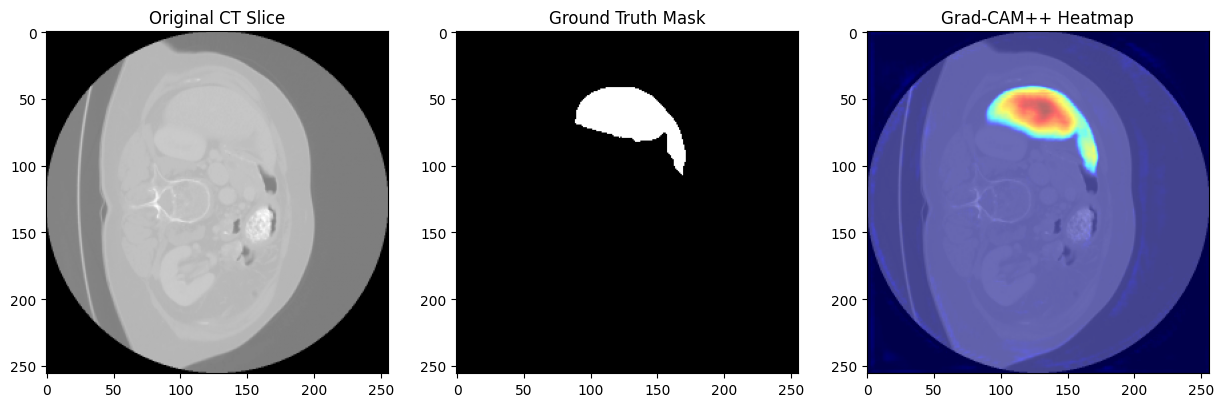

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import SemanticSegmentationTarget

# Path to one test image
img_path = "/content/lits_dataset/processed/images/img_0_50.png"
mask_path = "/content/lits_dataset/processed/masks/mask_0_50.png"

# Load and normalize grayscale image
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (256, 256))
img_norm = img / 255.0

input_tensor = torch.tensor(img_norm).unsqueeze(0).unsqueeze(0).float().to(device)

# ---- Grad-CAM++ setup ----
target_layers = [model.decoder.blocks[-1]]

cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

# Forward pass to get model output
with torch.no_grad():
    output = model(input_tensor)
    output_sigmoid = torch.sigmoid(output)
    output_np = output_sigmoid.cpu().numpy()[0, 0]

# Find the pixel with highest activation (most confident prediction)
class_idx = 0
mask_target = np.uint8(output_np > 0.5)
targets = [SemanticSegmentationTarget(class_idx, mask_target)]

# Compute Grad-CAM++
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

# Prepare image for overlay
rgb_img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB).astype(np.float32) / 255.0
cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# Load ground truth mask
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
mask = cv2.resize(mask, (256, 256))

# ---- Plot ----
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original CT Slice")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title("Ground Truth Mask")

plt.subplot(1, 3, 3)
plt.imshow(cam_image)
plt.title("Grad-CAM++ Heatmap")
plt.show()


In [ ]:
import os
import random
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import SemanticSegmentationTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from tqdm import tqdm

# ===============================
# Configuration
# ===============================
images_dir = "/content/lits_dataset/processed/images"
masks_dir = "/content/lits_dataset/processed/masks"
output_dir = "/content/lits_dataset/gradcam_results"
os.makedirs(output_dir, exist_ok=True)

# Randomly choose N images to visualize
N_SAMPLES = 5
sample_imgs = random.sample(os.listdir(images_dir), N_SAMPLES)

# Grad-CAM setup
target_layers = [model.decoder.blocks[-1]]
cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

# ===============================
# Generate Grad-CAM++ for samples
# ===============================
for name in tqdm(sample_imgs):
    img_path = os.path.join(images_dir, name)
    mask_path = os.path.join(masks_dir, name.replace("img_", "mask_"))

    # Load and preprocess
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    img = cv2.resize(img, (256, 256))
    img_norm = img / 255.0
    input_tensor = torch.tensor(img_norm).unsqueeze(0).unsqueeze(0).float().to(device)

    # Model forward pass
    with torch.no_grad():
        output = model(input_tensor)
        output_sigmoid = torch.sigmoid(output)
        output_np = output_sigmoid.cpu().numpy()[0, 0]

    # Create target mask for CAM
    class_idx = 0
    mask_target = np.uint8(output_np > 0.5)
    targets = [SemanticSegmentationTarget(class_idx, mask_target)]

    # Compute Grad-CAM++
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    # Prepare overlay image
    rgb_img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB).astype(np.float32) / 255.0
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Load ground truth mask
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, (256, 256))

    # Combine into visualization grid
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(img, cmap='gray')
    axs[0].set_title("Original CT Slice")
    axs[1].imshow(gt_mask, cmap='gray')
    axs[1].set_title("Ground Truth Mask")
    axs[2].imshow(cam_image)
    axs[2].set_title("Grad-CAM++ Heatmap")
    for ax in axs:
        ax.axis('off')

    # Save to file
    save_path = os.path.join(output_dir, name.replace(".png", "_gradcam.png"))
    plt.savefig(save_path, bbox_inches='tight')
    plt.close(fig)

print(f"✅ Saved {N_SAMPLES} Grad-CAM++ visualizations to {output_dir}")


100%|██████████| 5/5 [00:02<00:00,  2.06it/s]

✅ Saved 5 Grad-CAM++ visualizations to /content/lits_dataset/gradcam_results


In [ ]:
!ls /content/lits_dataset/gradcam_results


img_14_378_gradcam.png	img_39_220_gradcam.png	img_48_167_gradcam.png
img_27_469_gradcam.png	img_4_490_gradcam.png	img_9_450_gradcam.png
img_28_115_gradcam.png	img_46_42_gradcam.png
img_28_33_gradcam.png	img_46_50_gradcam.png


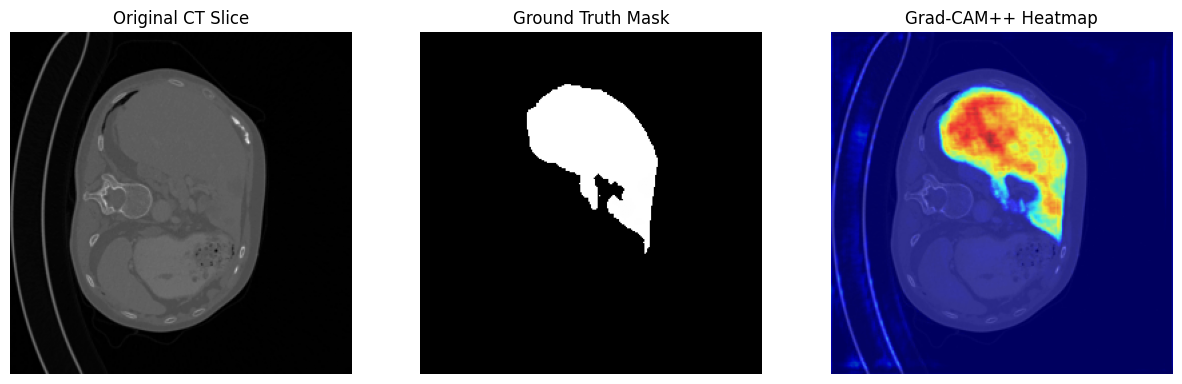

In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/lits_dataset/gradcam_results/img_27_469_gradcam.png"))


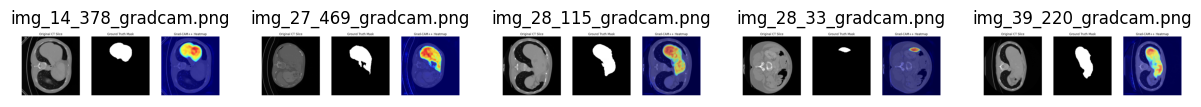

In [ ]:
import matplotlib.pyplot as plt
import cv2, os

result_dir = "/content/lits_dataset/gradcam_results"
files = sorted(os.listdir(result_dir))[:5]   # show first 5

plt.figure(figsize=(15,6))
for i, f in enumerate(files):
    img = cv2.imread(os.path.join(result_dir, f))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, len(files), i+1)
    plt.imshow(img)
    plt.title(f)
    plt.axis("off")
plt.show()


In [ ]:
torch.save(model.state_dict(), "/content/best_unet_model.pth")


In [ ]:
import torch
import cv2
import numpy as np
from PIL import Image
import nibabel as nib
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import SemanticSegmentationTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Load trained model ---
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,   # no need for pretrained weights now
    in_channels=1,
    classes=1
)
model.load_state_dict(torch.load("/content/best_unet_model.pth", map_location=device))
model.to(device)
model.eval()

# --- Inference function ---
def predict_ct_scan(file_path):
    # Step 1: Load image (NIfTI or PNG)
    if file_path.endswith(".nii") or file_path.endswith(".nii.gz"):
        img = nib.load(file_path).get_fdata()
        slice_idx = img.shape[2] // 2
        img = img[:, :, slice_idx]
    else:
        img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

    # Step 2: Preprocess
    img = cv2.resize(img, (256, 256))
    img_norm = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)
    input_tensor = torch.tensor(img_norm).unsqueeze(0).unsqueeze(0).float().to(device)

    # Step 3: Predict segmentation
    with torch.no_grad():
        output = model(input_tensor)
        mask_pred = torch.sigmoid(output).cpu().numpy()[0, 0]
        mask_bin = (mask_pred > 0.5).astype(np.uint8)

    # Step 4 (optional): Grad-CAM++
    target_layers = [model.decoder.blocks[-1]]
    cam = GradCAMPlusPlus(model=model, target_layers=target_layers)
    mask_target = np.uint8(mask_pred > 0.5)
    targets = [SemanticSegmentationTarget(0, mask_target)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    rgb_img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB).astype(np.float32) / 255.0
    cam_overlay = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Step 5: Prepare overlay result
    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    overlay[mask_bin == 1] = [0, 255, 0]  # green overlay for tumor

    return overlay, cam_overlay


In [ ]:
!pip install gradio


In [ ]:
import gradio as gr

def infer_and_display(file_obj):
    overlay, cam_overlay = predict_ct_scan(file_obj.name)
    overlay_img = Image.fromarray(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    cam_img = Image.fromarray(cv2.cvtColor(cam_overlay, cv2.COLOR_BGR2RGB))
    return [overlay_img, cam_img]

demo = gr.Interface(
    fn=infer_and_display,
    inputs=gr.File(label="Upload CT Scan (.nii or .png)"),
    outputs=[gr.Image(label="Segmented Output"),
             gr.Image(label="Grad-CAM++ Heatmap")],
    title="🧠 Liver Tumor Segmentation with Explainable AI",
    description="Upload a CT slice (.png) or NIfTI volume (.nii) to visualize segmentation and Grad-CAM++ explanation."
)

demo.launch(debug=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d68210d2dc06274239.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://d68210d2dc06274239.gradio.live


In [ ]:
from google.colab import drive
drive.flush_and_unmount()  # ensures no old mount remains
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
!cp /content/best_unet_model.pth /content/drive/MyDrive/best_unet_model.pth
print("✅ Model saved to Google Drive/MyDrive/")


cp: cannot stat '/content/best_unet_model.pth': No such file or directory
✅ Model saved to Google Drive/MyDrive/


In [ ]:
!ls -lh /content/drive/MyDrive/best_unet_model.pth


ls: cannot access '/content/drive/MyDrive/best_unet_model.pth': No such file or directory


In [ ]:
!ls /content/drive/MyDrive | head


2025-11-01 18-58-33.pdf
capstone 1[1].gdoc
Colab Notebooks
Copy of Scanned_20250718-1913.pdf
Ganesh 
git and github
IMG_20250707_142347.jpg
photo.jpg
Scanned_20250718-1913.pdf
Semwise Transcripts_22BCE7117_SR00010972_S.pdf


In [ ]:
!cp /content/best_unet_model.pth /content/drive/MyDrive/best_unet_model.pth
print("✅ Model copied to Drive!")


cp: cannot stat '/content/best_unet_model.pth': No such file or directory
✅ Model copied to Drive!
